In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("../data/retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df["Date"] = pd.to_datetime(df["Date"])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[us]
 2   Customer ID       1000 non-null   str           
 3   Gender            1000 non-null   str           
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   str           
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[us](1), int64(5), str(3)
memory usage: 70.4 KB


In [5]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

## Data Inspection Observation

The dataset contains retail transaction records with customer information, purchase dates, product categories, quantities, and transaction amounts. Date values were converted into datetime format to support customer purchase behavior analysis and RFM feature creation.

In [6]:
analysis_date = df["Date"].max()

analysis_date

Timestamp('2024-01-01 00:00:00')

In [7]:
rfm = df.groupby("Customer ID").agg({
    "Date": lambda x: (analysis_date - x.max()).days,
    "Transaction ID": "count",
    "Total Amount": "sum"
})

rfm.head()

,Date,Transaction ID,Total Amount
Customer ID,,,
CUST001,38,1,150
CUST002,308,1,1000
CUST003,353,1,30
CUST004,225,1,500
CUST005,240,1,100


In [8]:
rfm.columns = [
    "Recency",
    "Frequency",
    "Monetary"
]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
CUST001,38,1,150
CUST002,308,1,1000
CUST003,353,1,30
CUST004,225,1,500
CUST005,240,1,100


In [9]:
rfm.describe()

,Recency,Frequency,Monetary
count,1000.000000,1000.0,1000.000000
mean,181.982000,1.0,456.000000
std,105.276773,0.0,559.997632
min,0.000000,1.0,25.000000
25%,89.000000,1.0,60.000000
50%,185.500000,1.0,135.000000
75%,268.000000,1.0,900.000000
max,365.000000,1.0,2000.000000


## RFM Analysis Observation

Customer-level RFM analysis transforms individual transactions into behavioral features. Recency identifies how recently customers purchased, Frequency measures purchasing activity, and Monetary value represents customer spending contribution. These features will be used to identify customer segments with similar purchasing behaviors.

In [10]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)

rfm_scaled[:5]

array([[-1.36833645,  0.        , -0.5467043 ],
       [ 1.19761513,  0.        ,  0.97191876],
       [ 1.62527373,  0.        , -0.76109815],
       [ 0.40882261,  0.        ,  0.07861108],
       [ 0.55137548,  0.        , -0.63603507]])

In [11]:
rfm_scaled_df = pd.DataFrame(
    rfm_scaled,
    columns=rfm.columns,
    index=rfm.index
)

rfm_scaled_df.head()

,Recency,Frequency,Monetary
Customer ID,,,
CUST001,-1.368336,0.0,-0.546704
CUST002,1.197615,0.0,0.971919
CUST003,1.625274,0.0,-0.761098
CUST004,0.408823,0.0,0.078611
CUST005,0.551375,0.0,-0.636035


## Data Standardization Observation

RFM features have different measurement scales. Recency is measured in days, while Monetary represents currency values. StandardScaler was applied to normalize the features so that each variable contributes equally during K-Means clustering.

In [12]:
inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(rfm_scaled_df)
    
    inertia.append(kmeans.inertia_)

inertia

[2000.0,
 1188.7897684551258,
 617.6994312753977,
 430.7490864351307,
 344.4882505814244,
 284.2866973062507,
 237.70075115461248,
 195.1767495683996,
 166.40415737653035,
 149.76592895591085]

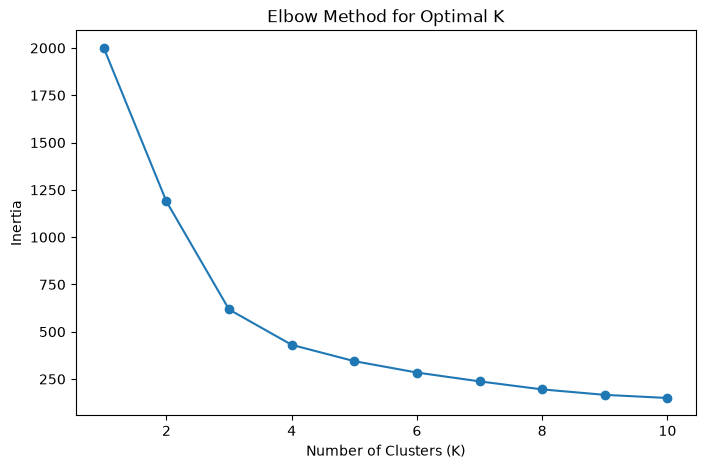

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

In [15]:
plt.savefig(
    "../images/elbow_method.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Elbow Method Observation

The Elbow Method was used to determine the optimal number of customer segments. The point where the reduction in inertia begins to slow indicates the appropriate number of clusters for the K-Means model.

In [16]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled_df)

rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
CUST001,38,1,150,1
CUST002,308,1,1000,2
CUST003,353,1,30,0
CUST004,225,1,500,0
CUST005,240,1,100,0


In [17]:
rfm["Cluster"].value_counts()

Cluster
1    392
0    380
2    228
Name: count, dtype: int64

In [18]:
cluster_profile = rfm.groupby("Cluster").mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,274.347368,1.0,167.881579
1,86.755102,1.0,211.237245
2,191.763158,1.0,1357.017544


## Customer Segment Profiles

K-Means clustering grouped customers into three segments based on purchasing behavior. Each cluster represents customers with similar recency, frequency, and monetary characteristics.

These segments can be used to develop targeted marketing strategies and improve customer engagement.

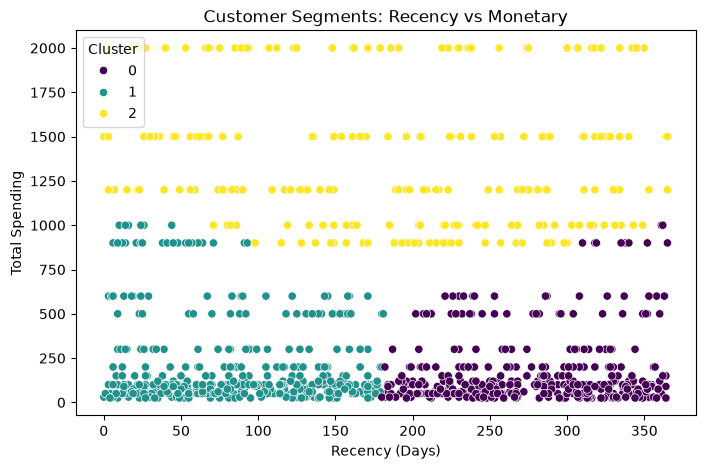

In [19]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="viridis"
)

plt.title("Customer Segments: Recency vs Monetary")
plt.xlabel("Recency (Days)")
plt.ylabel("Total Spending")

plt.savefig(
    "../images/cluster_recency_monetary.png",
    bbox_inches="tight"
)

plt.show()

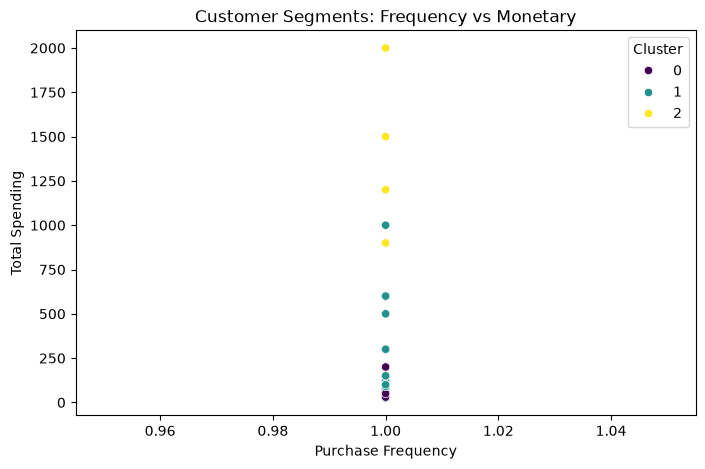

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="viridis"
)

plt.title("Customer Segments: Frequency vs Monetary")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Spending")

plt.savefig(
    "../images/cluster_frequency_monetary.png",
    bbox_inches="tight"
)

plt.show()

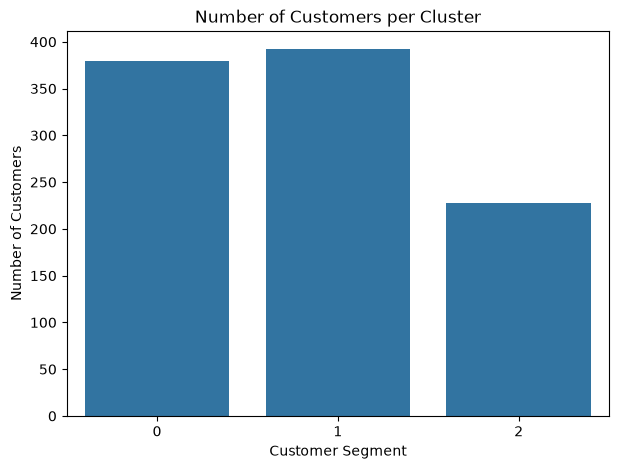

In [21]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=rfm,
    x="Cluster"
)

plt.title("Number of Customers per Cluster")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.savefig(
    "../images/customers_per_cluster.png",
    bbox_inches="tight"
)

plt.show()

# Customer Segmentation Insights

The K-Means clustering algorithm identified three distinct customer segments based on purchasing behavior.

## Cluster 0 — Inactive / Low-Value Customers

These customers have not purchased recently and have lower total spending.

### Marketing Recommendation:
- Launch re-engagement campaigns
- Provide personalized discounts
- Send product recommendations based on previous purchases

---

## Cluster 1 — Recent Customers

These customers have purchased more recently but have moderate spending levels.

### Marketing Recommendation:
- Encourage repeat purchases
- Introduce loyalty programs
- Offer incentives for their next purchase

---

## Cluster 2 — High-Value Customers

These customers generate the highest monetary value.

### Marketing Recommendation:
- Provide VIP rewards
- Offer exclusive promotions
- Give early access to new products

---

## Overall Business Recommendation

The company should use customer segmentation to create targeted marketing strategies instead of treating all customers the same. High-value customers should receive retention-focused campaigns, while inactive customers should receive reactivation offers.